# Coffee Quality Classification — Multiclass ML with scikit-learn Pipelines

**Question:** Can sensory scores and physical attributes predict specialty coffee quality class (Average / Good / Excellent)?

**Dataset:** [Coffee Quality Data (CQI May-2023)](https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi) · 207 Arabica samples, 41 features

**Year:** 2026

---

**Key finding:** Random Forest achieves 0.95 accuracy and 0.91 balanced accuracy, substantially above the 0.33 dummy baseline. Overfitting analysis shows the Decision Tree memorises training data from depth 5 onward, while optimal generalisation occurs at `max_depth = 4`.

---

## Notebook structure

| Phase | Content |
|-------|---------|
| **Phase 1 — EDA** | Dataset overview · column audit · 5 charts (distribution, processing method, sensory scores × class, altitude, correlations) · null analysis |
| **Phase 2 — Feature engineering** | Column selection · data-leakage prevention · altitude classification · PCA + t-SNE visualisation |
| **Phase 3 — Modelling** | Stratified 80/20 split · scikit-learn Pipeline (ColumnTransformer) · Random Forest vs Decision Tree vs Dummy baseline · Confusion matrices · Overfitting curve |


## Dependencies

In [1]:
# Install dependencies
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install kagglehub

## Imports

In [2]:
# Import libraries
import pandas as pd
import kagglehub
import re
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report,
    ConfusionMatrixDisplay
)

In [3]:
import random
import numpy as np

# For reproducibity
RNG_SEED = 0

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

---
# 1. Data & Exploration

## 1.1 Dataset overview

### About the data

- **Dataset name:** Coffee Quality Data (CQI May-2023)
- **Source:** https://www.kaggle.com/datasets/fatihb/coffee-quality-data-cqi
- **Description:** Compiled by the Coffee Quality Institute (CQI) with sensory and physical evaluations of 207 Arabica coffee samples assessed by certified Q-Graders. Contains sensory scores (Aroma, Flavor, Acidity, etc.), physical attributes (moisture, altitude, defects), and metadata (country, variety, processing method).
- **Prediction task:** Classify coffee quality into three categories (Average / Good / Excellent) derived from the Total Cup Points score. This allows identification of which physical and sensory attributes distinguish high-quality coffee.
- **Problem type:** Multiclass classification


### Downloading the data

In [5]:
# Kaggle credentials — load from environment variables (never hardcode keys)
# Set these in your terminal before running:
#   export KAGGLE_USERNAME='your-kaggle-username'
#   export KAGGLE_KEY='your-kaggle-api-key'
# Or create ~/.kaggle/kaggle.json — see https://www.kaggle.com/docs/api
import os
# os.environ['KAGGLE_USERNAME'] = 'YOUR_USERNAME'   # ← set in env, not here
# os.environ['KAGGLE_KEY']      = 'YOUR_API_KEY'    # ← set in env, not here

### Loading the data

In [6]:
# Load the dataset from Kaggle especifying the route
path = kagglehub.dataset_download('fatihb/coffee-quality-data-cqi')

print("Dataset download in:", path)

Using Colab cache for faster access to the 'coffee-quality-data-cqi' dataset.
Dataset download in: /kaggle/input/coffee-quality-data-cqi


In [7]:
import os
# Add table and verify first columns
coffee_file_path = os.path.join(path, 'df_arabica_clean.csv')
coffee = pd.read_csv(coffee_file_path)
coffee

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,202,202,Brazil,Fazenda Conquista,019/22,Dry Mill,NaN,Ipanema Coffees,950,Sul de Minas,...,80.08,11.4,0,0,green,4,"February 2nd, 2024",Brazil Specialty Coffee Association,"Rua Gaspar Batista Paiva, 416 – Santa Luiza Va...",Chris Allen - 55 35 3212-4705
203,203,203,Nicaragua,Finca San Felipe,017-053-0155,Beneficio Atlantic Sébaco,017-053-0155,Exportadora Atlantic S.A,1200,Matagalpa,...,80.00,10.4,0,2,green,12,"March 2nd, 2024",Asociación de Cafés Especiales de Nicaragua,"Del Hotel Seminole 2 C al lago, 1 C arriba.",Maria Ines Benavidez Toval - 011-(505)-8396 4717
204,204,204,Laos,-,105/3/VL7285-005,DRY MILL,105/3/VL7285-005,Marubeni Corporation,1300,Bolaven Plateau,...,79.67,11.6,0,9,green,11,"November 11th, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
205,205,205,El Salvador,"Rosario de Maria II, Area de La Pila",0423A01,"Optimum Coffee, San Salvador, El Salvador",NaN,Aprentium Enterprises LLC,1200,"Volcan de San Vicente, La Paz, El Salvador",...,78.08,11.0,0,12,bluish-green,13,"March 7th, 2024",Salvadoran Coffee Council,"Final 1a. Av. Norte y 13 Calle Pte., dentro de...",Tomas Bonilla - (503) 2505-6600


In [8]:
coffee.shape

(207, 41)

The dataset is small — only 207 rows — but has 41 features, which makes it descriptively rich despite its size. Depending on which variables are kept for modelling, the goal is to retain as much information as possible without removing outliers, to avoid further reducing the dataset.


## 1.2 Column analysis

In [10]:
info_columnas = [
    # (column name, estatistic_type, brief_description, role)
    ('Unnamed: 0',            'Continuous numerics',    'Data order',                                          'Identifier'),
    ('ID',                    'Continuous numerics',    'Sample number',                                       'Identifier'),
    ('Country of Origin',     'Nominal categorical',    'Country where the coffee was grown',                  'Predictor'),
    ('Farm Name',             'Nominal categorical',    'Name of the estate or farm',                          'Identifier'),
    ('Lot Number',            'Nominal categorical',    'Batch number assigned to the coffee',                 'Identifier'),
    ('Mill',                  'Nominal categorical',    'Name of the mill where it was processed',             'Identifier'),
    ('ICO Number',            'Nominal categorical',    'Code of the International Coffee Organisation',       'Identifier'),
    ('Company',               'Nominal categorical',    'Exporting company or owner',                          'Identifier'),
    ('Altitude',              'Text/mixed',             'Altitude in metres',                                  'Classification category'),
    ('Region',                'Nominal categorical',    'Geographical region of cultivation',                  'Predictor'),
    ('Producer',              'Nominal categorical',    'Producer’s name',                                     'Identifier'),
    ('Number of Bags',        'Integer',                'Number of bags in the evaluated batch',               'Predictor'),
    ('Bag Weight',            'Text/mixed',             'Bag weight',                                          'Mixed text'),
    ('In-Country Partner',    'Nominal categorical',    'Partner organisation in the country of originn',      'Identifier'),
    ('Harvest Year',          'Date / text',            'Coffee harvest year',                                 'Date'),
    ('Grading Date',          'Date',                   'Date on which the grading took place',                'Date'),
    ('Owner',                 'Nominal categorical',    'Property owners',                                     'Identifier'),
    ('Variety',               'Nominal categorical',    'Botanical variety of coffee',                         'Predictor'),
    ('Status',                'Nominal categorical',    'Analysis status',                                     'Identifier'),
    ('Processing Method',     'Nominal categorical',    'Processing method',                                   'Predictor'),
    ('Aroma',                 'Continuous numerics',    'Sensory aroma score (scale 0–10)',                    'Predictor'),
    ('Flavor',                'Continuous numerics',    'Sensory flavour score (scale 0–10)',                  'Predictor'),
    ('Aftertaste',            'Continuous numerics',    'Sensory aftertaste score (scale 0–10)',               'Predictor'),
    ('Acidity',               'Continuous numerics',    'Sensory acidity score (scale 0–10)',                  'Predictor'),
    ('Body',                  'Continuous numerics',    'Sensory body score (scale 0–10)',                     'Predictor'),
    ('Balance',               'Continuous numerics',    'Sensory overall balance score (scale 0–10)',          'Predictor'),
    ('Uniformity',            'Continuous numerics',    'Uniformity between cups in the sample (scale 0–10)',  'Predictor'),
    ('Clean Cup',             'Continuous numerics',    'Cup cleanliness, absence of off-flavours 0–10',       'Predictor'),
    ('Sweetness',             'Continuous numerics',    'Cup sweetness (scale 0–10)',                          'Predictor'),
    ('Overall',               'Continuous numerics',    'Expert taster’s overall score (scale 0–10)',          'Predictor'),
    ('Defects',               'Continuous numerics',    'Undesirable qualities',                               'Predictor'),
    ('Total Cup Points',      'Continuous numerics',    'Sum of all sensory scores',                           'Predictor'),
    ('Moisture Percentage',   'Continuous numerics',    'Moisture content of green grain',                     'Predictor'),
    ('Category One Defects',  'Integer',                'Number of serious defects (Category 1)',              'Predictor'),
    ('Quakers',               'Continuous numerics',    'Immature grains',                                     'Predictor'),
    ('Color',                 'Nominal categorical',    'Grain colour',                                        'Predictor'),
    ('Category Two Defects',  'Integer',                'Number of minor defects (Category 2)',                'Predictor'),
    ('Expiration',            'Date',                   'Certification expiry date',                           'Date'),
    ('Certification Body',    'Nominal categorical',    'Certifying body',                                     'Identifier'),
    ('Certification Address', 'Nominal categorical',    'Address of the certifying bodyr',                     'Identifier'),
    ('Certification Contact', 'Nominal categorical',    'Contact details for the certifying body',             'Identifier')]


# List the columns, the number of non-null values and the data type
coffee_summary = pd.DataFrame({
    'Type' : coffee.dtypes,
    'Null' : coffee.isnull().sum(),
    'Null %' : (coffee.isnull().sum() / len(coffee) * 100).map('{:.2f}'.format),
    'Unique Values': coffee.nunique()
})

sem = pd.DataFrame(
    info_columnas,
    columns = ['Column', 'Variable Type', 'Description', 'Role in the Analysis']
)
sem = sem.set_index('Column')

table_columns = coffee_summary.join(sem, how = 'left')
table_columns.index.name = 'Column'

# Mostrar tabla completa
table_columns.style.set_properties(**{'text-align': 'left'})

,Type,Null,Null %,Unique Values,Variable Type,Description,Role in the Analysis
Column,,,,,,,
Unnamed: 0,int64,0,0.00,207,Continuous numerics,Data order,Identifier
ID,int64,0,0.00,207,Continuous numerics,Sample number,Identifier
Country of Origin,object,0,0.00,22,Nominal categorical,Country where the coffee was grown,Predictor
Farm Name,object,2,0.97,172,Nominal categorical,Name of the estate or farm,Identifier
Lot Number,object,1,0.48,187,Nominal categorical,Batch number assigned to the coffee,Identifier
Mill,object,3,1.45,162,Nominal categorical,Name of the mill where it was processed,Identifier
ICO Number,object,132,63.77,67,Nominal categorical,Code of the International Coffee Organisation,Identifier
Company,object,0,0.00,72,Nominal categorical,Exporting company or owner,Identifier
Altitude,object,1,0.48,97,Text/mixed,Altitude in metres,Classification category


The dataset contains a mix of continuous numeric and nominal categorical variables. Most columns are identifiers unique to each sample and do not contribute to the predictive model. The most informative columns are the sensory scores. Columns with the most nulls are ICO Number, Variety, and Processing Method.


In [11]:
coffee.describe()

,Unnamed: 0,ID,Number of Bags,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean Cup,Sweetness,Overall,Defects,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Category Two Defects
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000,207.0,207.0,207.000000,207.0,207.000000,207.000000,207.000000,207.000000,207.000000
mean,103.000000,103.000000,155.449275,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,9.990338,10.0,10.0,7.676812,0.0,83.706570,10.735266,0.135266,0.690821,2.251208
std,59.899917,59.899917,244.484868,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,0.103306,0.0,0.0,0.306359,0.0,1.730417,1.247468,0.592070,1.686918,2.950183
min,0.000000,0.000000,1.000000,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,8.670000,10.0,10.0,6.670000,0.0,78.000000,0.000000,0.000000,0.000000,0.000000
25%,51.500000,51.500000,1.000000,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,10.000000,10.0,10.0,7.500000,0.0,82.580000,10.100000,0.000000,0.000000,0.000000
50%,103.000000,103.000000,14.000000,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,10.000000,10.0,10.0,7.670000,0.0,83.750000,10.800000,0.000000,0.000000,1.000000
75%,154.500000,154.500000,275.000000,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,10.000000,10.0,10.0,7.920000,0.0,84.830000,11.500000,0.000000,1.000000,3.000000
max,206.000000,206.000000,2240.000000,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,10.000000,10.0,10.0,8.580000,0.0,89.330000,13.500000,5.000000,12.000000,16.000000


**Classification of Objective Variables**

In [13]:
# Create the ‘Quality Class’ target variable with three quality categories
def classify_quality(score):
    if score < 82:
        return 'Average'
    elif score <= 85:
        return 'Good'
    else:
        return 'Excellent'

coffee['Quality Class'] = coffee['Total Cup Points'].apply(classify_quality)

print('Distribution of the target variable "Quality Class":')
print(coffee['Quality Class'].value_counts().to_string())
print(f"\nProportion of classes:")
print(coffee['Quality Class'].value_counts(normalize=True).round(3).to_string())

Distribution of the target variable "Quality Class":
Quality Class
Good         136
Excellent     43
Average       28

Proportion of classes:
Quality Class
Good         0.657
Excellent    0.208
Average      0.135


The Quality Class variable was divided into 3 categories for the classification model. The split was made using the thresholds defined by the Specialty Coffee Association (SCA).


**Variable Altitude Classification**

In [15]:
# Modify the Altitude variable in categories

def datos_altitude(val):
  if pd.isna(val):
    return np.nan
  nums = re.findall(r'\d+\.?\d*', str(val))
  if not nums:
    return np.nan
  avg = sum([float(n) for n in nums]) / len(nums)
  if avg > 3000:
    avg = avg * 0.3048
  return avg

coffee['Altitude_m'] = coffee['Altitude'].apply(datos_altitude)

# Analyse the distribution to define thresholds based on the data
print('Altitude distribution (metres):')
print(coffee['Altitude_m'].describe().round(1).to_string())
print()

Altitude distribution (metres):
count     206.0
mean     1243.3
std       490.3
min       139.0
25%      1010.0
50%      1321.2
75%      1600.0
max      2361.0



In [16]:
# Classify according to the observed distribution

def classify_altitude(meters):
  if pd.isna(meters):
    return 'Unknown'
  elif meters < 1000:
    return 'Bajo'
  elif meters <= 1500:
    return 'Medio'
  else:
    return 'Alto'

coffee['Altitude_Class'] = coffee['Altitude_m'].apply(classify_altitude)

print('Distribution of Altitude_Class:')
print(coffee['Altitude_Class'].value_counts().to_string())

Distribution of Altitude_Class:
Altitude_Class
Medio      96
Alto       62
Bajo       48
Unknown     1


To define the altitude thresholds, I analysed the distribution of the Altitude column. The classification is based on observed growing altitudes and how coffee quality varies with elevation. Values above 3000 (from Vietnam, Guatemala, and Ethiopia) were treated as feet rather than metres, since at that altitude it is too cold for coffee to grow.


Total Cup Points is the variable from which the target label is derived. Visualising its distribution confirms that the chosen thresholds produce classes with sufficient samples.


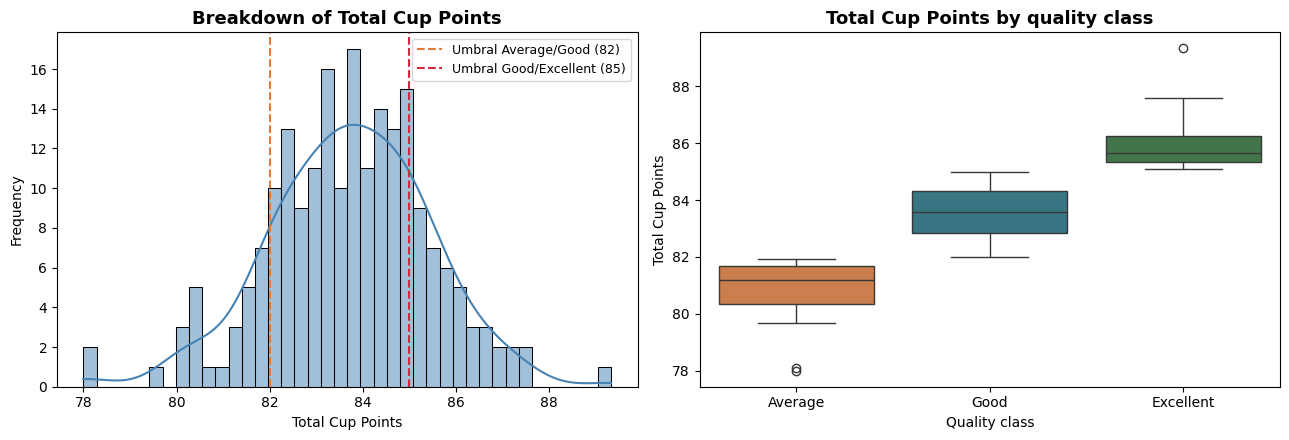

count    207.00
mean      83.71
std        1.73
min       78.00
25%       82.58
50%       83.75
75%       84.83
max       89.33
Name: Total Cup Points, dtype: float64


In [17]:
# Create a histogram and box plot of Total Cup Points
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram + KDE
sns.histplot(coffee['Total Cup Points'].dropna(), bins=40, kde=True,
             color='steelblue', ax=axes[0])
axes[0].axvline(82, color='#E07B39', linestyle='--',
                label='Umbral Average/Good (82)')
axes[0].axvline(85, color='#D7263D',    linestyle='--',
                label='Umbral Good/Excellent (85)')
axes[0].set_title('Breakdown of Total Cup Points', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Cup Points')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Box plot per class
order_clase = ['Average', 'Good', 'Excellent']
palette = {'Average': '#E07B39', 'Good': '#2A7F8F', 'Excellent': '#3A7D44'}
sns.boxplot(data=coffee, x='Quality Class', y='Total Cup Points',
            order=order_clase, palette=palette, ax=axes[1])
axes[1].set_title('Total Cup Points by quality class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Quality class')
axes[1].set_ylabel('Total Cup Points')

plt.tight_layout()
plt.show()
print(coffee['Total Cup Points'].describe().round(2))

The distribution of Total Cup Points is approximately normal with a slight left tail, concentrated between 80 and 87 points. The values 82 and 85 divide the distribution, placing the central zone in the Good class (the most frequent), Excellent on the right, and Average on the left.
The boxplot confirms that the 3 classes are differentiated without overlapping, indicating that classification is feasible.

Processing Method was included because the processing method directly affects the sensory profile of the coffee. It is a categorical variable used as a predictor. Its distribution reveals potential category imbalance.


Processing Method fue usado dado que el método de procesamiento afecta directamente el perfíl sensorial del café. Es una variable categórica que se incluye como predictor. Ver su distribución avisa de posible desbalance de categorías.

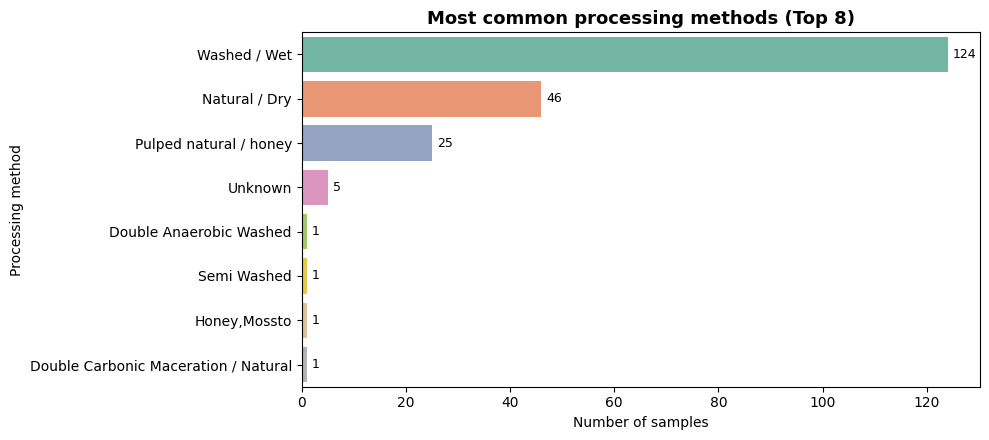

Full breakdown of the processing method:
Processing Method
Washed / Wet                            124
Natural / Dry                            46
Pulped natural / honey                   25
NaN                                       5
Double Anaerobic Washed                   1
Semi Washed                               1
Honey,Mossto                              1
Double Carbonic Maceration / Natural      1
Wet Hulling                               1
Anaerobico 1000h                          1
SEMI-LAVADO                               1


In [18]:
# Create a bar chart using the Processing Method
fig, ax = plt.subplots(figsize=(10, 4.5))

procesos = (coffee['Processing Method']
               .fillna('Unknown')
               .value_counts()
               .head(8))

bars = sns.barplot(x=procesos.values, y=procesos.index,
                   palette='Set2', ax=ax)

# Value labels on each bar
for i, v in enumerate(procesos.values):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

ax.set_title('Most common processing methods (Top 8)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Processing method')
plt.tight_layout()
plt.show()

print("Full breakdown of the processing method:")
print(coffee['Processing Method'].value_counts(dropna=False).to_string())

The Washed/Wet method is the most common, representing more than 50% of samples, and Natural/Dry is the second most common at around 25%. This imbalance may cause the model to over-represent the Washed/Wet method. The Unknown category confirms the need to handle null values.


Sensory scores by class were visualised to confirm that the quality classes are genuinely differentiated in the features used for prediction. If there were no differences, the model would not be able to learn to separate the classes.


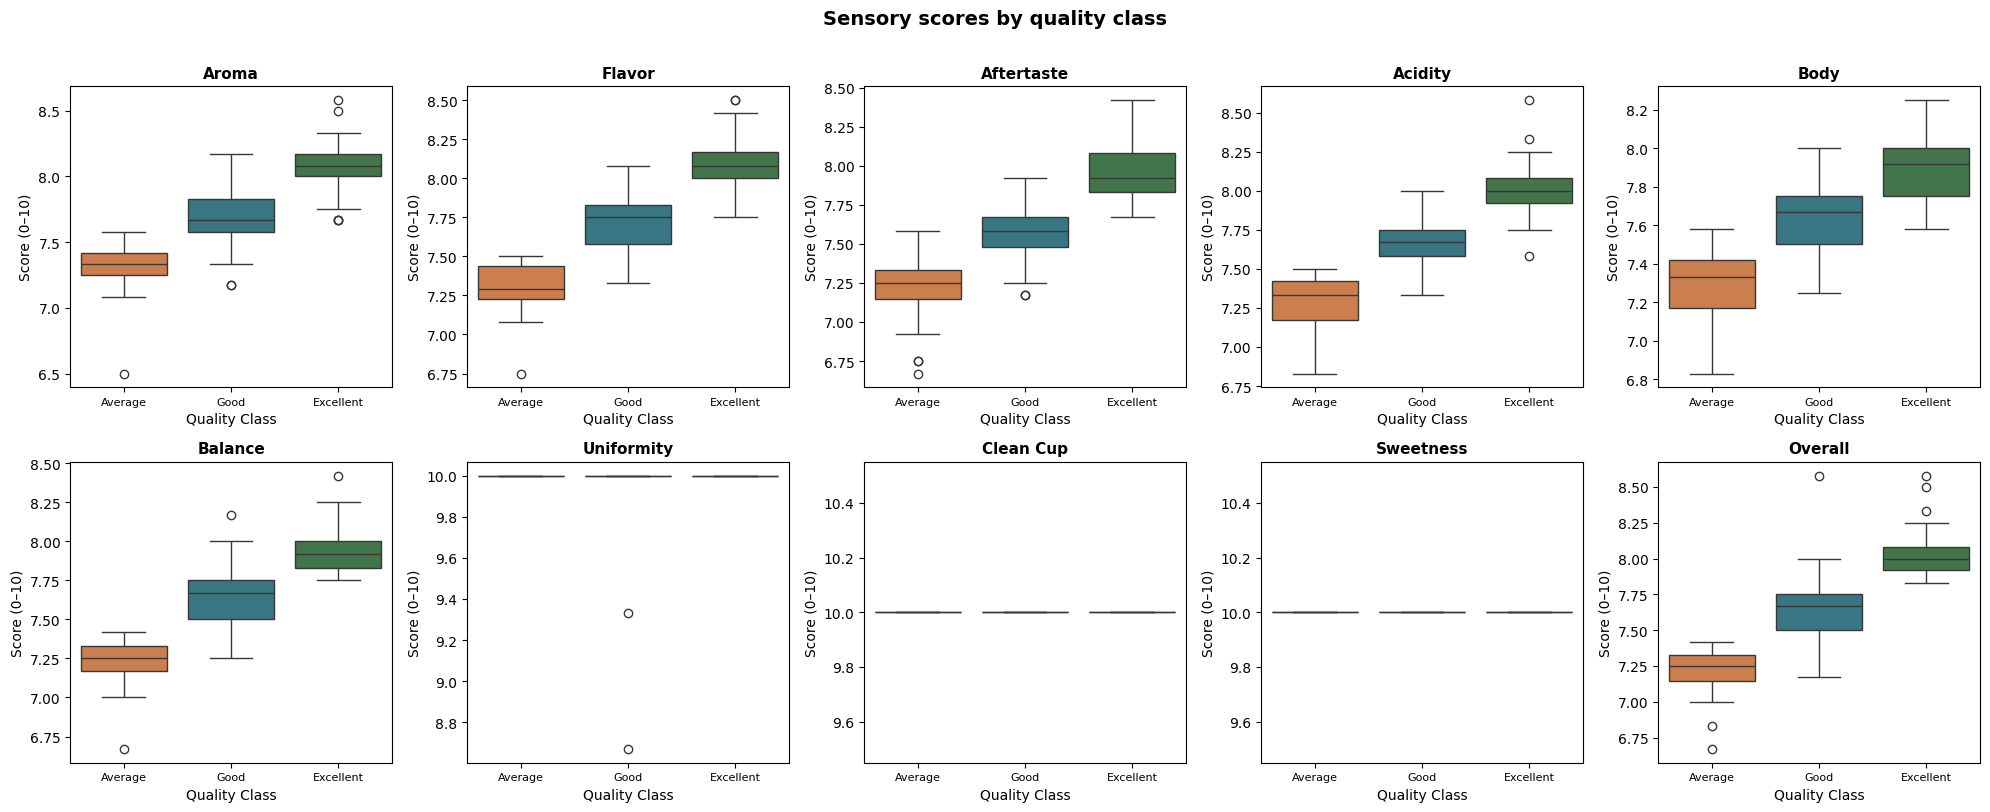

In [19]:
# Create a Bloxpot using the sensory variables and the target
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
                'Uniformity', 'Clean Cup', 'Sweetness', 'Overall']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(sensory_cols):
    sns.boxplot(data=coffee, x='Quality Class', y=col,
                order=order_clase, palette=palette, ax=axes[i])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Quality Class')
    axes[i].set_ylabel('Score (0–10)')
    axes[i].tick_params(axis='x', labelsize=8)

fig.suptitle('Sensory scores by quality class',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The sensory scores show a rising trend from Average to Excellent, meaning higher-quality coffees score higher on 5 of the variables. The scores are strong predictors of quality class. Uniformity, Clean Cup, and Sweetness have values very close to 10.

Altitude distribution was visualised to validate the chosen thresholds against actual data. If the histogram shows that data naturally cluster around those values, the classification has empirical support.


Distribución de altitud se usó para justificar con datos los úmbrales elegidos. Si el histograma muestra que lso datos se agrupan naturalmente alrededor de esos valores, la clasificación tiene respaldo.

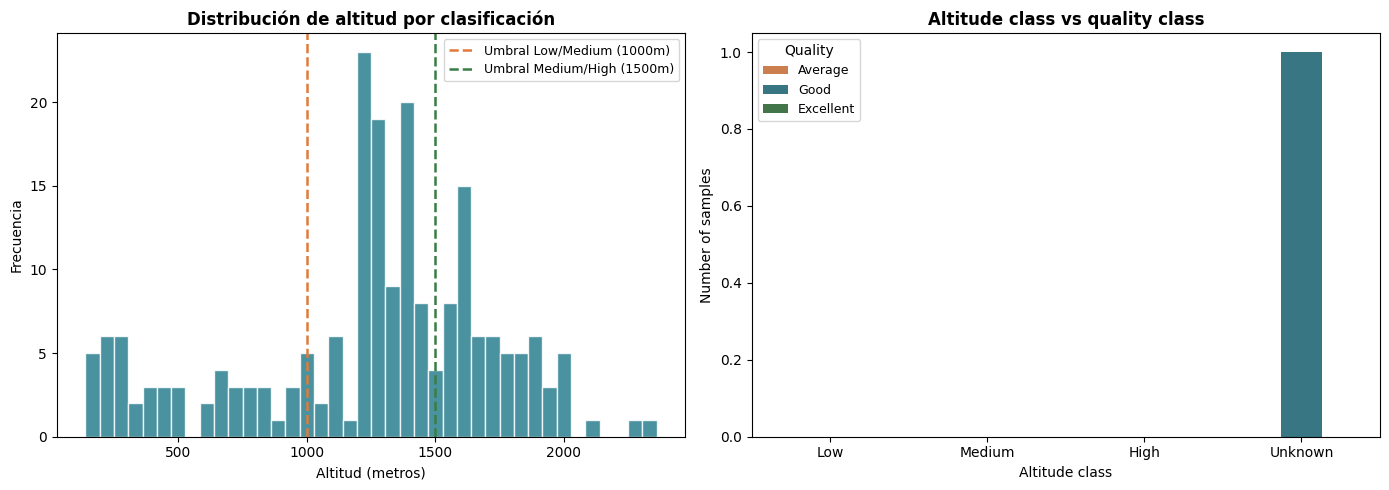

In [ ]:
# Histogram showing height classifications
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(coffee['Altitude_m'].dropna(), bins=40,
             color='#2A7F8F', edgecolor='white', alpha=0.85)
axes[0].axvline(1000, color='#E07B39', linestyle='--', linewidth=1.8,
                label='Umbral Low/Medium (1000m)')
axes[0].axvline(1500, color='#3A7D44', linestyle='--', linewidth=1.8,
                label='Umbral Medium/High (1500m)')
axes[0].set_title('Altitude distribution by clasification',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Altitud (meters)')
axes[0].set_ylabel('Frecuency')
axes[0].legend(fontsize=9)

# Count by altitude class vs. quality class
alt_order = ['Low', 'Medium', 'High', 'Unknown']
sns.countplot(data=coffee, x='Altitude_Class', hue='Quality Class',
              order=alt_order, hue_order=order_clase,
              palette=palette, ax=axes[1])
axes[1].set_title('Altitude class vs quality class',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Altitude class')
axes[1].set_ylabel('Number of samples')
axes[1].legend(title='Quality', fontsize=9)

plt.tight_layout()
plt.show()

The histogram shows that most samples are concentrated between 1000m and 2000m. The category boundaries at 1000m and 1500m divide the data into 3 groups with sufficient samples, validating the choice. The bar chart shows that high-altitude coffees tend to have more Excellent samples, confirming that altitude is a relevant variable for predicting quality.

Detecting outliers shows where there are defective beans that could cause the model to learn incorrect rules. The correlation heatmap helps identify which features are most related to each other, informing decisions about removing redundant features.


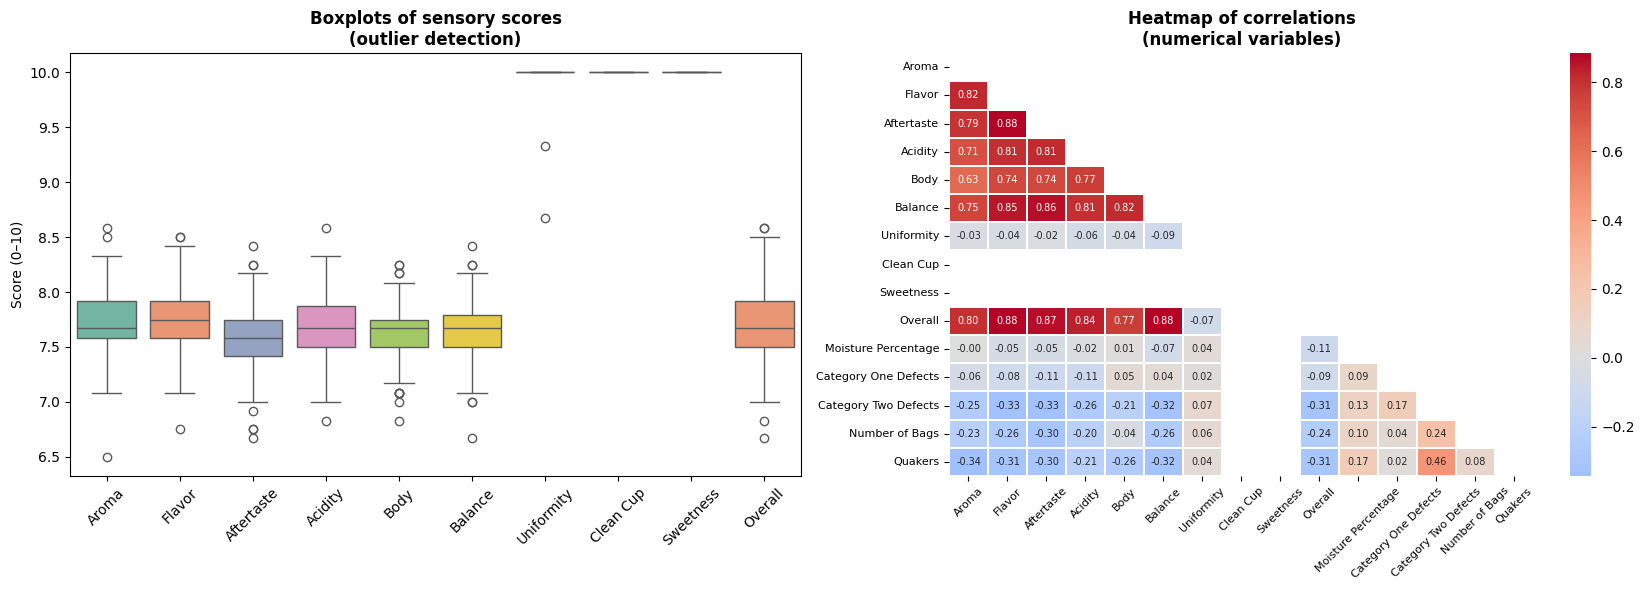

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Boxplots of outliers
sensory_cols = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance',
               'Uniformity', 'Clean Cup', 'Sweetness', 'Overall']

df_melt = coffee[sensory_cols].melt(var_name='Score', value_name='Value')
sns.boxplot(data=df_melt, x='Score', y='Value',
            palette='Set2', ax=axes[0])
axes[0].set_title('Boxplots of sensory scores\n(outlier detection)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score (0–10)')
axes[0].tick_params(axis='x', rotation=45)

# Correlation heatmap
num_cols_corr = sensory_cols + ['Moisture Percentage', 'Category One Defects',
                               'Category Two Defects', 'Number of Bags', 'Quakers']
corr_matrix = coffee[num_cols_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3,
            annot_kws={'size': 7}, ax=axes[1])
axes[1].set_title('Heatmap of correlations\n(numerical variables)',
                  fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

The boxplot shows that Uniformity, Clean Cup, and Sweetness have outliers at 0, corresponding to lots with serious defects. Aroma, Flavor, and Body have more compact distributions with outliers in the lower range.

The correlation heatmap shows that sensory scores have strong positive correlations with each other, which makes sense since they measure aspects of the same coffee. Non-sensory variables have low or no correlation with sensory scores, indicating that bag quantity or defects do not directly determine the sensory quality of the coffee.


## 1.3 Handling of null values

Columns with null values: 10
                   Null  % Null
ICO Number          132   63.77
Variety               6    2.90
Processing Method     5    2.42
Mill                  3    1.45
Region                2    0.97
Farm Name             2    0.97
Lot Number            1    0.48
Altitude              1    0.48
Producer              1    0.48
Altitude_m            1    0.48


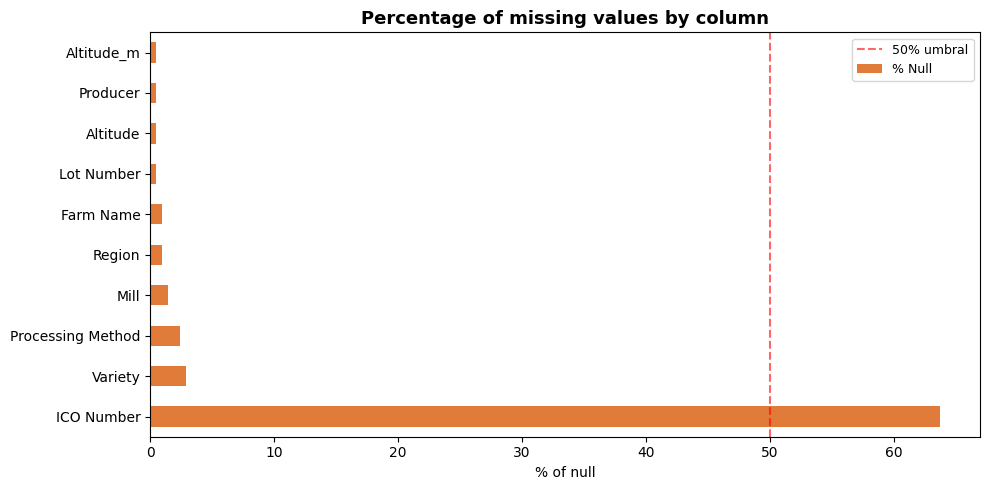

In [24]:
# Show any null values present
nulls    = coffee.isnull().sum()
null_pct = (nulls / len(coffee) * 100).round(2)
null_coffee  = pd.DataFrame({'Null': nulls, '% Null': null_pct})
null_coffee  = null_coffee[null_coffee['Null'] > 0].sort_values('% Null', ascending=False)

print(f"Columns with null values: {len(null_coffee)}")
print(null_coffee.to_string())

# Displaying null values
fig, ax = plt.subplots(figsize=(10, 5))
null_coffee['% Null'].plot(kind='barh', color='#E07B39', ax=ax)
ax.set_title('Percentage of missing values by column', fontsize=13, fontweight='bold')
ax.set_xlabel('% of null')
ax.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% umbral')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Null value treatment will be applied to training data inside the preprocessing pipeline to prevent data leakage. This section presents the analysis only.

- **Altitude:** median of the training set, given the asymmetric distribution of outliers. It will be modified before use.
- **Variety:** many varieties exist, so an additional category is created to preserve information.
- **Processing Method and Color:** mode of the training set, given the low number of nulls.
- **Quakers and other numeric columns:** median of the training set.


---
# 2. Feature Engineering

## 2.1 Feature Selection

In [26]:
# Remove columns that are not relevant to the model
COLS_DROP = [
    'Unnamed: 0', 'ID', 'Owner',
    'Farm Name', 'Lot Number', 'Mill', 'ICO Number', 'Company', 'Producer',
    'In.Country Partner', 'Certification Body',
    'Certification Address', 'Certification Contact',
    'Altitude', 'Altitude_m',   # Altitude_Class is retained as a predictor
    'Grading.Date', 'Harvest.Year', 'Expiration',
    'Bag Weight',
    'Total Cup Points' # DATA LEAKAGE: direct source from Quality Class
]

# We only remove the ones that exist
cols_to_drop = [col for col in COLS_DROP if col in coffee.columns]
coffee_clean = coffee.drop(columns=cols_to_drop).copy()

- **Unnamed: 0:** corresponds to the species label and does not contribute relevant information.
- **ID and Owner:** identifiers, repeated.
- **Farm Name, Lot Number, Mill, ICO Number, Company, Producer:** lot-level identifiers.
- **In Country Partner, certifications:** organisational identifiers, not relevant.
- **Altitude, Altitude_m:** removed; Altitude_Class is kept instead.
- **Grading Date, Harvest Year, Expiration:** dates with many nulls.
- **Bag Weight:** low relevance.
- **Total Cup Points:** data leakage, as it is the sum of the sensory scores and the source of Quality Class.


In [27]:
# Define X and Y
TARGET = 'Quality Class'
feature_cols = [col for col in coffee_clean.columns if col != TARGET]

X = coffee_clean[feature_cols].copy()
y = coffee_clean[TARGET].copy()

# Identify feature types for the pipeline
num_feats = X.select_dtypes(include = [np.number]).columns.tolist()
cat_feats = X.select_dtypes(include = ['object', 'category']).columns.tolist()

print(f'Final fataset: {X.shape[0]:,} filas x {X.shape[1]} features + 1 target')
print(f'\nNumerical features ({len(num_feats)}):')
print(num_feats)
print(f'\nCategorical features ({len(cat_feats)}):')
print(cat_feats)
print(f'\nTarget distribution:')
print(y.value_counts().to_string())

Final fataset: 207 filas x 26 features + 1 target

Numerical features (16):
['Number of Bags', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean Cup', 'Sweetness', 'Overall', 'Defects', 'Moisture Percentage', 'Category One Defects', 'Quakers', 'Category Two Defects']

Categorical features (10):
['Country of Origin', 'Region', 'In-Country Partner', 'Harvest Year', 'Grading Date', 'Variety', 'Status', 'Processing Method', 'Color', 'Altitude_Class']

Target distribution:
Quality Class
Good         136
Excellent     43
Average       28


Although Uniformity, Clean Cup, and Sweetness showed extreme outliers at 0 corresponding to lots with serious defects, I chose to retain them because they represent real information, not errors. These are precisely the attributes that distinguish low-quality coffees. Removing those columns would discard important quality information that is central to this analysis and model.


## 2.2 Dimension Reduction

The chosen technique is t-SNE with PCA as a preliminary step.

Since the goal is to visually explore whether the quality classes form separable clusters, t-SNE is the most appropriate method. It handles non-linear clusters and allows an exploratory visualisation that reveals local structure.


In [28]:
# X processing for display
num_pipe_vis = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipe_vis = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc_vis = ColumnTransformer([
    ('num', num_pipe_vis, num_feats),
    ('cat', cat_pipe_vis, cat_feats)
])

X_proc = preproc_vis.fit_transform(X)
print(f'Shape after pre-processing: {X_proc.shape}')

Shape after pre-processing: (207, 336)


In [29]:
# Step 1: 50-dimensional PCA
n_pca = min(50, X_proc.shape[1])
pca_pre = PCA(n_components = n_pca, random_state = RNG_SEED)
X_pca_pre = pca_pre.fit_transform(X_proc)
var_total = pca_pre.explained_variance_ratio_.sum() * 100
print(f'Variance explained by {n_pca} PCA components: {var_total:.1f}%')

Variance explained by 50 PCA components: 93.2%


PCA was applied before t-SNE because with many features the computation becomes slow. Reducing first to 50 components with PCA significantly speeds up t-SNE without losing relevant information.


In [30]:
# Step 2: 2D t-SNE
tsne = TSNE(n_components=2,
            perplexity=30,
            n_iter=1000,
            random_state=RNG_SEED,
            learning_rate='auto',
            init='pca'
)

X_tsne = tsne.fit_transform(X_pca_pre)

Justification for t-SNE hyperparameters:
- **perplexity=30:** recommended default value. Controls the balance between local and global structure.
- **n_iter=1000:** sufficient for algorithm convergence given the dataset size.
- **random_state=RNG_SEED:** ensures reproducibility.
- **init='pca':** initialising with PCA accelerates convergence and produces more stable results.


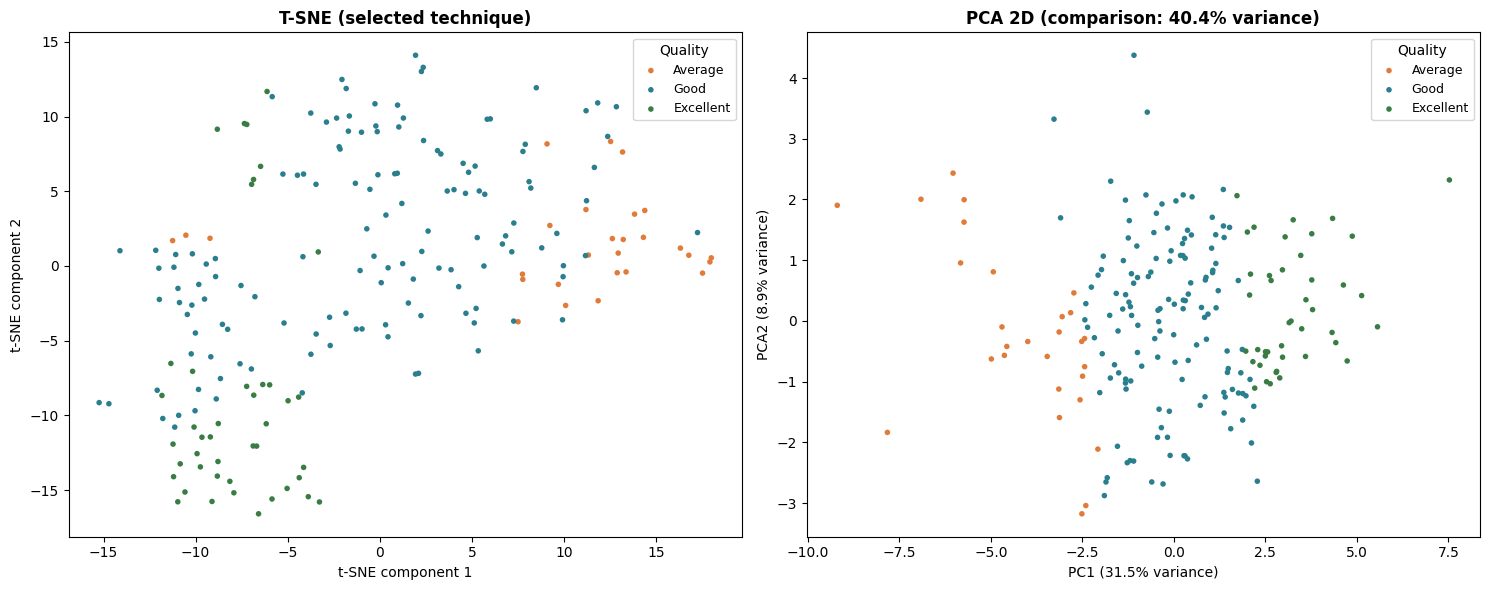


2D PCA – variance explained:
 PC1: 31.48%
 PC2: 8.89%
 Total of 2 components: 40.36%


In [31]:
# Calculate 2D PCA for comparison
pca_2d = PCA(n_components=2, random_state=RNG_SEED)
X_pca_2d = pca_2d.fit_transform(X_proc)
var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

# Displaying both
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, X_2d, title, xlabel, ylabel in [
    (axes[0], X_tsne, 'T-SNE (selected technique)',
     't-SNE component 1', 't-SNE component 2'),
    (axes[1], X_pca_2d, f'PCA 2D (comparison: {var1+var2:.1f}% variance)',
     f'PC1 ({var1:.1f}% variance)', f'PCA2 ({var2:.1f}% variance)')
]:
    for cls in ['Average', 'Good', 'Excellent']:
      mask = (y == cls)
      ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                 c=palette[cls], label=cls,
                 alpha=1.0, s=16, edgecolors='none')
      ax.set_title(title, fontsize=12, fontweight='bold')
      ax.set_xlabel(xlabel)
      ax.set_ylabel(ylabel)
      ax.legend(title = 'Quality', fontsize=9)

plt.tight_layout()
plt.show()

# Variance explained by PCA component
print(f'\n2D PCA – variance explained:')
print(f' PC1: {var1:.2f}%')
print(f' PC2: {var2:.2f}%')
print(f' Total of 2 components: {var1+var2:.2f}%')

t-SNE reveals that the 3 classes form relatively distinct regions, though with overlap between Good and Excellent. Average points tend to cluster at the edges of the plot, away from the core.

PCA 2D captures between 30 and 40% of total variance, which explains why the clusters are less defined. Two principal components are not sufficient to separate the classes.

The visible overlap between Good and Excellent in t-SNE indicates that the model will need to combine multiple features to distinguish them, unlike Average, which is the most clearly separable.

The cluster structure in t-SNE is continuous rather than discrete, which is expected given that class boundaries are arbitrary thresholds on a continuous scale.


---
# 3. Modelling and Evaluation

## 3.1 Train / test split

In [32]:
# 80/20 stratified partitioning
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RNG_SEED
)

print(f'Train size: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)')
print()
print('Class distribution in TRAIN:')
print(y_train.value_counts().to_string())
print()
print('Class allocation in TEST:')
print(y_test.value_counts().to_string())
print()
print('Relative proportion (should be similar in both partitions):')
print(pd.DataFrame({
    'Train (%)': y_train.value_counts(normalize=True).round(3) * 100,
    'Test (%)':  y_test.value_counts(normalize=True).round(3) * 100
}).to_string())

Train size: 165 samples (79.7%)
Test size:  42 samples (20.3%)

Class distribution in TRAIN:
Quality Class
Good         109
Excellent     34
Average       22

Class allocation in TEST:
Quality Class
Good         27
Excellent     9
Average       6

Relative proportion (should be similar in both partitions):
               Train (%)  Test (%)
Quality Class                     
Good                66.1      64.3
Excellent           20.6      21.4
Average             13.3      14.3


Proportion: 80% train and 20% test. A larger test split would leave too few samples for training. 80/20 was preferred over 70/30 because with a small dataset it is more critical to maximise training data than to widen the test set.

Stratification: yes (stratify=y). The classes are imbalanced. Without stratification the test set could be missing samples from a class, making evaluation impossible. With such a small and imbalanced dataset, there is a real risk that the test set would contain no Average samples. Stratification guarantees that each class has the same proportion in both splits.

Random state: RNG_SEED = 0. Ensures reproducibility.


## 3.2 Model training

I compared two models: **Random Forest** and **Decision Tree**.

Random Forest is the natural choice for tabular classification: its ensemble structure reduces variance, handles irrelevant features, and does not require feature scaling. The Decision Tree serves as an interpretable complement: its single-tree structure makes overfitting patterns transparent, which is useful for the analysis in Section 3.3.

Three metrics were reported:

- **Balanced accuracy** (primary): average recall per class, which prevents the majority class from dominating the score on an imbalanced dataset.
- **F1-score macro:** weights precision and recall equally across all three classes, regardless of class size.
- **Confusion matrix:** shows which classes are confused with each other, not just the overall error rate.


In [33]:
# Define the processor
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc = ColumnTransformer([
    ('num', num_pipeline, num_feats),
    ('cat', cat_pipeline, cat_feats)
])

Using Pipeline and ColumnTransformer encapsulates preprocessing inside the model, guaranteeing that the median, mode, and scaler never see the test data and thus preventing data leakage.

Null values are not imputed here but inside the Pipeline below. This was done intentionally to avoid leakage. By encapsulating imputation in the Pipeline, scikit-learn fits exclusively on X_train and applies it to the test set only at prediction time:
- Numeric features: SimpleImputer(strategy='median')
- Categorical features: SimpleImputer(strategy='most_frequent')


**Model 1: Random Forest**

In [34]:
rf_pipe = Pipeline([
    ('prep', preproc),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)

print('=' * 60)
print('MODELO 1: Random Forest (n_estimators=100)')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_rf, average='macro'):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Average', 'Excellent', 'Good']))

MODELO 1: Random Forest (n_estimators=100)
Balanced Accuracy : 0.9074
Accuracy          : 0.9524
F1-score (macro)  : 0.9382

              precision    recall  f1-score   support

     Average       1.00      0.83      0.91         6
   Excellent       1.00      0.89      0.94         9
        Good       0.93      1.00      0.96        27

    accuracy                           0.95        42
   macro avg       0.98      0.91      0.94        42
weighted avg       0.96      0.95      0.95        42



The model achieves balanced accuracy of 0.9074 and accuracy of 0.9524. Good is the majority class (27/42 samples in the test set) and the model identifies it perfectly (recall=1.0). Errors are concentrated in Average and Excellent, both with 6 samples, where the model misses 1 sample from each class, likely classifying it as Good. The high precision for Average and Excellent (1.0) indicates that when the model predicts those classes, it is never wrong. The macro F1 of 0.94 confirms strong and consistent performance across all 3 classes.


**Model 2: Decision Tree**

In [35]:
dt_pipe = Pipeline([
    ('prep', clone(preproc)), # prevents models from sharing the same pre-processor
    ('model', DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)

print('=' * 60)
print('MODEL 2: Decision Tree (max_depth=10)')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_dt):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_dt, average='macro'):.4f}')
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Average', 'Excellent', 'Good']))

MODEL 2: Decision Tree (max_depth=10)
Balanced Accuracy : 0.9259
Accuracy          : 0.9048
F1-score (macro)  : 0.9077

              precision    recall  f1-score   support

     Average       1.00      1.00      1.00         6
   Excellent       0.73      0.89      0.80         9
        Good       0.96      0.89      0.92        27

    accuracy                           0.90        42
   macro avg       0.90      0.93      0.91        42
weighted avg       0.92      0.90      0.91        42



The Decision Tree achieves higher balanced accuracy than Random Forest (0.9259 vs 0.9077), classifying Average perfectly (f1=1.0). However, its precision on Excellent is lower (0.73) and it tends to over-predict that class. By comparison, Random Forest is more consistent across classes, while the Decision Tree is more extreme: perfect on Average but less precise on Excellent.


**Baseline: DummyClassifier**

In [36]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RNG_SEED)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('=' * 60)
print('BASELINE: DummyClassifier')
print('=' * 60)
print(f'Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred_dummy):.4f}')
print(f'F1-score (macro)  : {f1_score(y_test, y_pred_dummy, average='macro'):.4f}')
print()

BASELINE: DummyClassifier
Balanced Accuracy : 0.3333
Accuracy          : 0.6429
F1-score (macro)  : 0.2609



The DummyClassifier achieves accuracy of 0.6429 simply by predicting Good at all times, since it represents 64% of the test set. However, its balanced accuracy is 0.3333, equivalent to random guessing, and its macro F1 of 0.2609 reflects that it never predicts Average or Excellent. This confirms that accuracy alone is a misleading metric with imbalanced classes, and validates the use of balanced accuracy as the primary metric.


In [37]:
# Comparison table
summary = pd.DataFrame({
    'Modelo': ['DummyClassifier (baseline)', 'Árbol de Decisión', 'Random Forest'],
    'Balanced Accuracy': [
        balanced_accuracy_score(y_test, y_pred_dummy),
        balanced_accuracy_score(y_test, y_pred_dt),
        balanced_accuracy_score(y_test, y_pred_rf)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]

}).set_index('Modelo').round(4)

print('COMPARISON TABLE:')
print(summary.to_string())

COMPARISON TABLE:
                            Balanced Accuracy  Accuracy  F1-score (macro)
Modelo                                                                   
DummyClassifier (baseline)             0.3333    0.6429            0.2609
Árbol de Decisión                      0.9259    0.9048            0.9077
Random Forest                          0.9074    0.9524            0.9382


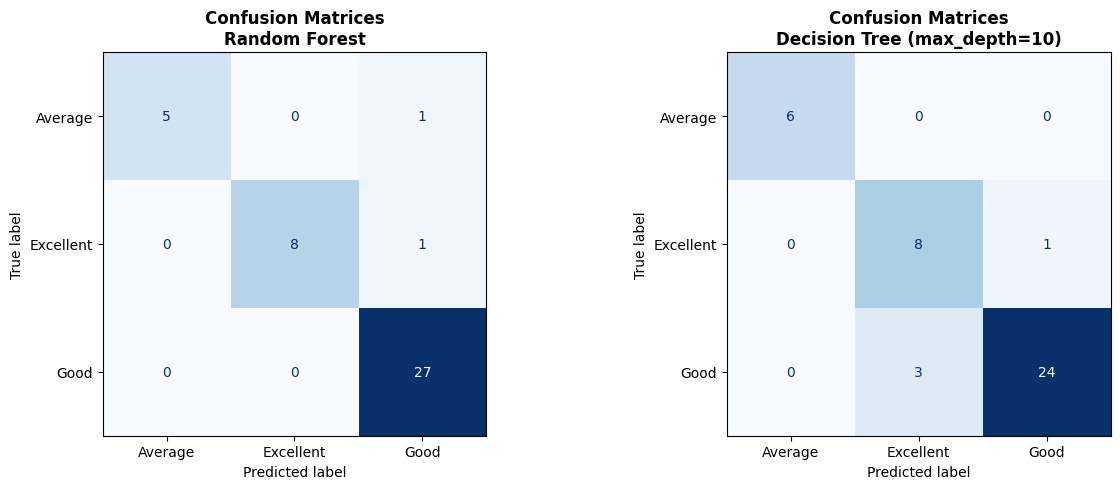

In [39]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = ['Average', 'Excellent', 'Good']

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_dt],
    ['Random Forest', 'Decision Tree (max_depth=10)']):
  ConfusionMatrixDisplay.from_predictions(
      y_test, y_pred,
      display_labels=class_labels,
      colorbar=False,
      cmap='Blues',
      ax=ax
  )
  ax.set_title(f'Confusion Matrices\n{title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Comparative model analysis:
- **Random Forest:** outperformed the Decision Tree on all metrics, especially balanced accuracy. The ensemble of 100 trees reduces model variance and improves generalisation, which is particularly valuable with only 207 samples.
- **Decision Tree:** substantially outperformed the baseline, but makes more errors on the minority classes Average and Excellent. A single misclassification has a large impact.
- Both models consistently outperform the Dummy, confirming that the learned patterns are real.
- Balanced accuracy is more informative than plain accuracy. The Dummy can achieve over 60% accuracy by always predicting Good, but its balanced accuracy is only 0.33.
- **Limitation:** since the test set contains 42 samples with only 6 in the minority class, results should be interpreted with caution.


## 3.3 Overfitting Analysis

I used the Decision Tree to demonstrate overfitting, since `max_depth` provides a single interpretable control over model complexity, making it straightforward to observe the divergence between training and test sets. Random Forest is not well suited to this analysis because the averaging across 100 trees masks individual tree overfitting by design.

Varying `max_depth` from 1 to 30 answers a clear question: at what depth does the tree stop generalising and start memorising? Balanced accuracy is used on both splits for consistency with the rest of the evaluation.


In [40]:
depths = list(range(1, 31))
train_scores = []
test_scores = []

for depth in depths:
  pipe_ov = Pipeline([
    ('prep', clone(preproc)), # prevents models from sharing the same pre-processor
    ('model', DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=RNG_SEED
  ))
])
  pipe_ov.fit(X_train, y_train)
  train_scores.append(balanced_accuracy_score(y_train, pipe_ov.predict(X_train)))
  test_scores.append(balanced_accuracy_score(y_test, pipe_ov.predict(X_test)))


# Finding the optimal depth in a test
best_idx   = int(np.argmax(test_scores))
best_depth = depths[best_idx]
best_score = test_scores[best_idx]

print(f'Optimal depth on the test set = {best_depth}')
print(f'Balanced accuracy on the test set : {best_score:.4f}')
print(f'Balanced accuracy on the training set: {train_scores[best_idx]:.4f}')

Optimal depth on the test set = 4
Balanced accuracy on the test set : 0.9259
Balanced accuracy on the training set: 0.9908


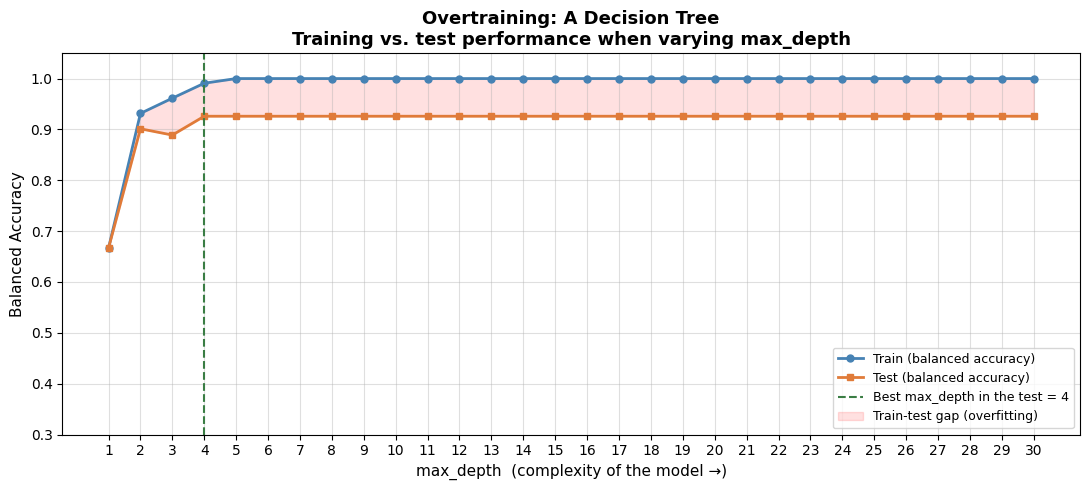

In [41]:
# Overfitting graph
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, train_scores, 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Train (balanced accuracy)')
ax.plot(depths, test_scores, 's-', color='#E07B39',
        linewidth=2, markersize=5, label='Test (balanced accuracy)')
ax.axvline(best_depth, color='#3A7D44', linestyle='--', linewidth=1.5,
           label=f'Best max_depth in the test = {best_depth}')
ax.fill_between(depths, train_scores, test_scores,
                alpha=0.12, color='red', label='Train-test gap (overfitting)')

ax.set_title('Overtraining: A Decision Tree\n'
             'Training vs. test performance when varying max_depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('max_depth  (complexity of the model →)', fontsize=11)
ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_xticks(depths)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [42]:
# Summary table
result_ov = pd.DataFrame({
    'max_depth': depths,
    'Train Balanced Acc': np.round(train_scores, 4),
    'Test Balanced Acc':  np.round(test_scores, 4),
    'Gap (train-test)': np.round(np.array(train_scores) - np.array(test_scores), 4)
})
print('\nSummary by depth (first and last rows):')
print(pd.concat([result_ov.head(8), result_ov.tail(5)]).to_string(index=False))


Summary by depth (first and last rows):
 max_depth  Train Balanced Acc  Test Balanced Acc  Gap (train-test)
         1              0.6667             0.6667            0.0000
         2              0.9315             0.9012            0.0302
         3              0.9614             0.8889            0.0725
         4              0.9908             0.9259            0.0649
         5              1.0000             0.9259            0.0741
         6              1.0000             0.9259            0.0741
         7              1.0000             0.9259            0.0741
         8              1.0000             0.9259            0.0741
        26              1.0000             0.9259            0.0741
        27              1.0000             0.9259            0.0741
        28              1.0000             0.9259            0.0741
        29              1.0000             0.9259            0.0741
        30              1.0000             0.9259            0.0741


The chart shows that the optimal depth is max_depth=4, with balanced accuracy of 0.9259 on test and 0.9908 on train. From depth 5 onward, train accuracy reaches 1.0 and the tree completely memorises the training data, while the test stabilises at 0.9259 with a constant gap of 0.07. This behaviour is common in small datasets: overfitting occurs in a single depth step and the test score stops declining because the tree has exhausted its memorisation capacity with only 207 samples.
